In [ ]:
import pennylane as pl
from pennylane import numpy as np
import matplotlib.pyplot as plt
import math

In [10]:
n_qubits = 1
dev = pl.device("default.qubit", wires=n_qubits)


In [11]:
@pl.qnode(dev) # assim que se faz um circuito
def circuit():
    pl.Hadamard(wires=0)
    return pl.probs(wires=[0])
circuit()

array([0.5, 0.5])

In [12]:
dev = pl.device("default.qubit", wires=n_qubits) 
@pl.qnode(dev) # assim que se faz um circuito
def circuit():
    pl.Hadamard(wires=0)
    return pl.state()
circuit()[0]

np.complex128(0.7071067811865475+0j)

[0. 0. 0. 1.]


(<Figure size 500x300 with 1 Axes>, <Axes: >)

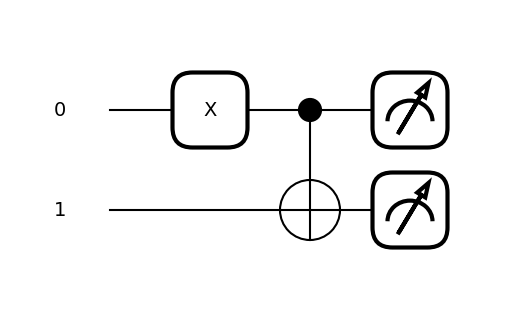

In [13]:
n_qubits = 2
dev = pl.device("default.qubit", wires=n_qubits)
@pl.qnode(dev)
def circuit():
    pl.PauliX(wires=0)
    pl.CNOT(wires=[0,1])
    return pl.probs(wires=[0,1]) # gets the probability of each basis state (|00>, |01>, |10>, |11>) !!!!!!!!!!!!!!!!!!!!!!!!!
print(circuit())
pl.draw_mpl(circuit)()

Gates: 

Paulix é o NOT 

CNOT

Hadamard: colocar em superposição

### Algoritmo de Grover

escolher um numero de 1 até N quero achar o numero certo

primeiro falar de Deutsch-Jozsa!



In [14]:
def function(n_qubits, id=0):
    def oracle():
        if id == 0:
            # Constant function (always 0)
            pass
        elif id == 1:
            # Constant function (always 1)
            pl.PauliX(wires=n_qubits) # Flip ancilla
        else:
            # Balanced function (example: XOR with first qubit) ISSO EH UM EXEMPLO DE UMA FUNÇAO
            for i in range(n_qubits):
                pl.CNOT(wires=[i, n_qubits])
    return oracle

In [15]:
import pennylane as pl

def Deutsch_Jozsa(nqubits_input, nqubits_ancilla=1, id=0):
    n_qubits = nqubits_input + nqubits_ancilla
    
    # Adicionado shots=1 para simular a vantagem quântica de uma única execução
    dev = pl.device("default.qubit", wires=n_qubits, shots=1000)
    
    @pl.qnode(dev)
    def circuit():
        for i in range(nqubits_input, n_qubits):
            pl.PauliX(wires=i)


        for i in range(n_qubits): 
            pl.Hadamard(wires=i)


        function(nqubits_input, id)() 


        for i in range(nqubits_input):
            pl.Hadamard(wires=i)

        return pl.sample(wires=range(nqubits_input))
    
    return circuit

# --- Testando ---
n = 3

# Teste com Função Constante (espera-se apenas 0s)
print("Teste Constante (id=0):", Deutsch_Jozsa(nqubits_input=n, id=0)())

# Teste com Função Constante Invertida (espera-se apenas 0s)
print("Teste Constante (id=1):", Deutsch_Jozsa(nqubits_input=n, id=1)())

# Teste com Função Balanceada (espera-se pelo menos um 1)
print("Teste Balanceado (id=2):", Deutsch_Jozsa(nqubits_input=n, id=2)())



Teste Constante (id=0): [[0 0 0]
 [0 0 0]
 [0 0 0]
 ...
 [0 0 0]
 [0 0 0]
 [0 0 0]]
Teste Constante (id=1): [[0 0 0]
 [0 0 0]
 [0 0 0]
 ...
 [0 0 0]
 [0 0 0]
 [0 0 0]]
Teste Balanceado (id=2): [[1 1 1]
 [1 1 1]
 [1 1 1]
 ...
 [1 1 1]
 [1 1 1]
 [1 1 1]]


/Users/josepedro/Downloads/Uni/venv311/lib/python3.11/site-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Resultado da medição com PauliZ: [array([-1.]), array([-1.]), array([-1.]), array([-1.])]


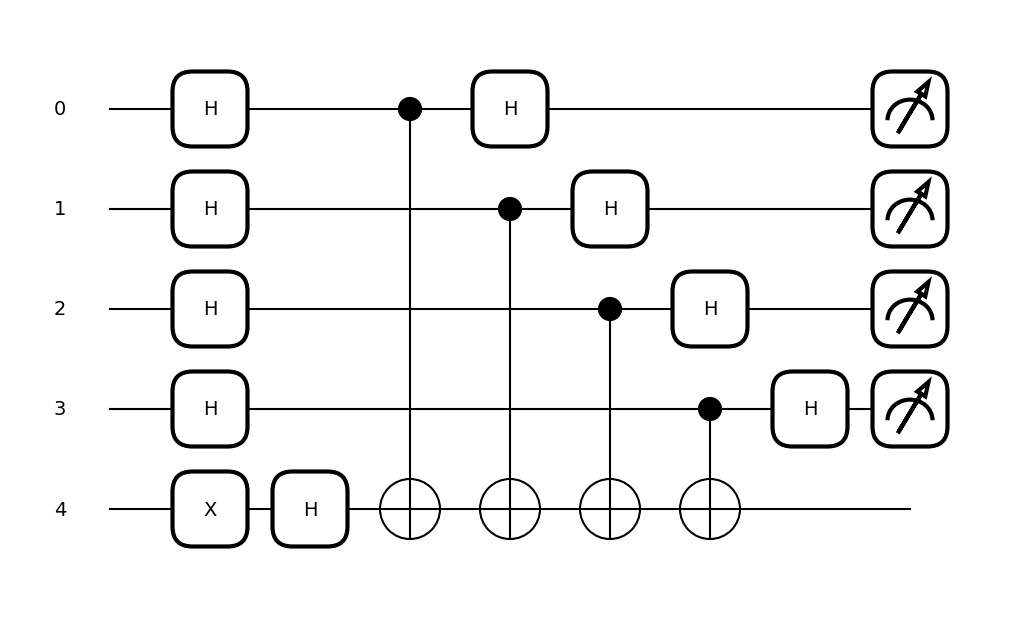

In [16]:
import pennylane as pl

# (Assumindo que a sua definição do Oráculo 'function' está carregada aqui)

def Deutsch_Jozsa(nqubits_input, nqubits_ancilla=1, id=0):
    n_qubits = nqubits_input + nqubits_ancilla
    
    # CORREÇÃO DO ERRO: Adicionado 'shots=1' para o pl.sample() funcionar
    dev = pl.device("default.qubit", wires=n_qubits, shots=1)
    
    @pl.qnode(dev)
    def circuit():
        # ATENÇÃO: Removi o loop do PauliX nos qubits de entrada.
        # É obrigatório que eles comecem em 0 para o algoritmo funcionar.
        
        for i in range(nqubits_input, n_qubits):
            pl.PauliX(wires=i)

        for i in range(n_qubits): # todos os qbits com sobreposiçao
            pl.Hadamard(wires=i)

        function(nqubits_input, id)() # apliquei o oraclo

        for i in range(nqubits_input):
            pl.Hadamard(wires=i)

        # A SUA FORMA ORIGINAL DE MEDIR
        return [pl.sample(pl.PauliZ(wires=i)) for i in range(nqubits_input)]
    pl.draw_mpl(circuit)()
    return circuit

n = 4
fid = 67

# Executando o circuito
resultado = Deutsch_Jozsa(nqubits_input=n, id=fid)()
print("Resultado da medição com PauliZ:", resultado)





In [17]:
#-----------------------.-.-.-.-.-.-.-.-.-.-.-.-.

n_qubits = 3

wires = list(range(n_qubits))

chave = [0]*3 

dev = pl.device("default.qubit", wires=n_qubits)

def oraculo(): #?!??!?!??!?!?!?!??!?!?!?!?!?!?!?!?!?!?!?!?!?!??!?!??!
    pl.FlipSign(chave,wires=wires)

def best_iter(n):
    return math.floor((math.pi/4)*math.sqrt(2**n))

def difusao():
    for wire in wires:
        pl.Hadamard(wires=wire)

    for wire in wires:
        pl.PauliX(wires=wire)

    pl.ctrl(pl.PauliZ(wires=wires[-1]),control=wires[:-1])

    for wire in wires:
        pl.PauliX(wires=wire)

    for wire in wires:
        pl.Hadamard(wires=wire)

    

@pl.qnode(dev)
def grover(iter):
    for wire in wires:
        pl.Hadamard(wires=wire)

    for _ in range(iter):
        oraculo()
        difusao()
    return pl.probs(wires=wires)


grover(best_iter(n_qubits))




array([0.9453125, 0.0078125, 0.0078125, 0.0078125, 0.0078125, 0.0078125,
       0.0078125, 0.0078125])

(<Figure size 1000x400 with 1 Axes>, <Axes: >)

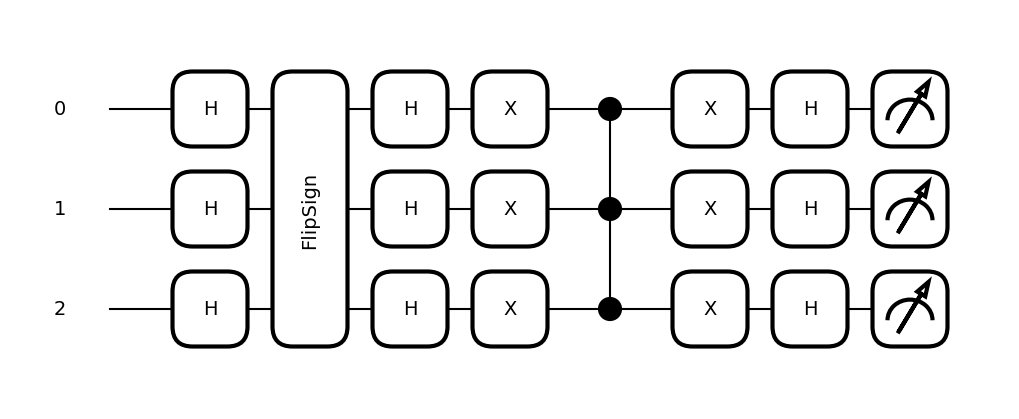

In [18]:
pl.draw_mpl(grover)(1)

In [26]:
import pennylane as pl
import numpy as np

def grover2(n_qubits, ids, iterations="optimal"):
    # Create registers
    input_registers = list(range(n_qubits))
    ancilla_register = n_qubits # Simpler as an integer
    
    # 1. Superposition
    for wire in input_registers:
        pl.Hadamard(wires=wire)

    # Put ancilla in the |-> state for phase kickback
    pl.PauliX(wires=ancilla_register)
    pl.Hadamard(wires=ancilla_register)
    
    pl.Barrier()
    
    # Calculate optimal iterations if requested
    if iterations == "optimal":
        its = round(np.pi/4 * np.sqrt(2**n_qubits) - 0.5)
    else:
        its = iterations

    for _ in range(its):
        # 2. ORACLE
        all_wires = input_registers + [ancilla_register]

        pl.MultiControlledX(wires=all_wires, control_values=ids)

        pl.Barrier()
        
        # 3. DIFFUSION OPERATOR
        for w in input_registers:
            pl.Hadamard(wires=w)
            
        for w in input_registers:
            pl.PauliX(wires=w)
            
        # Multi-controlled Z gate using pl.ctrl
        pl.ctrl(pl.PauliZ, control=input_registers[:-1])(wires=input_registers[-1])
        
        for w in input_registers:
            pl.PauliX(wires=w)
            
        for w in input_registers:
            pl.Hadamard(wires=w)
            
        pl.Barrier()
        
    # 4. Measurement
    return pl.probs(wires=input_registers)

In [32]:
n_qubits = 4
id = [0,1,1,0]

dev = pl.device("default.qubit", wires=n_qubits+1)
Grover = pl.QNode(grover2, dev)

grover2(n_qubits, id, iterations=1)

probs(wires=[0, 1, 2, 3])

In [28]:
import pennylane as pl
import numpy as np

def grover2(n_qubits, ids, iterations="optimal"):
    # Create registers
    input_registers = list(range(n_qubits))
    ancilla_register = n_qubits # Simpler as an integer
    
    # 1. Superposition
    for wire in input_registers:
        pl.Hadamard(wires=wire)

    # Put ancilla in the |-> state for phase kickback
    pl.PauliX(wires=ancilla_register)
    pl.Hadamard(wires=ancilla_register)
    
    pl.Barrier()
    
    # Calculate optimal iterations if requested
    if iterations == "optimal":
        its = round(np.pi/4 * np.sqrt(2**n_qubits) - 0.5)
    else:
        its = iterations

    for _ in range(its):
        # 2. ORACLE
        all_wires = input_registers + [ancilla_register]

        pl.MultiControlledX(wires=all_wires, control_values=ids)

        pl.Barrier()
        
        # 3. DIFFUSION OPERATOR
        for w in input_registers:
            pl.Hadamard(wires=w)
            
        for w in input_registers:
            pl.PauliX(wires=w)
            
        # Multi-controlled Z gate using pl.ctrl
        pl.ctrl(pl.PauliZ, control=input_registers[:-1])(wires=input_registers[-1])
        
        for w in input_registers:
            pl.PauliX(wires=w)
            
        for w in input_registers:
            pl.Hadamard(wires=w)
            
        pl.Barrier()
        
    # 4. Measurement
    return pl.probs(wires=input_registers)

In [34]:
n_qubits = 3
dev = pl.device("default.qubit", wires=n_qubits + 1) # +1 for the ancilla

@pl.qnode(dev)
def run_grover():
    return grover2(n_qubits, ids=[1, 0, 1])

results = run_grover()
print(results)

[0.0078125 0.0078125 0.0078125 0.0078125 0.0078125 0.9453125 0.0078125
 0.0078125]


(<Figure size 1400x400 with 1 Axes>, <Axes: >)

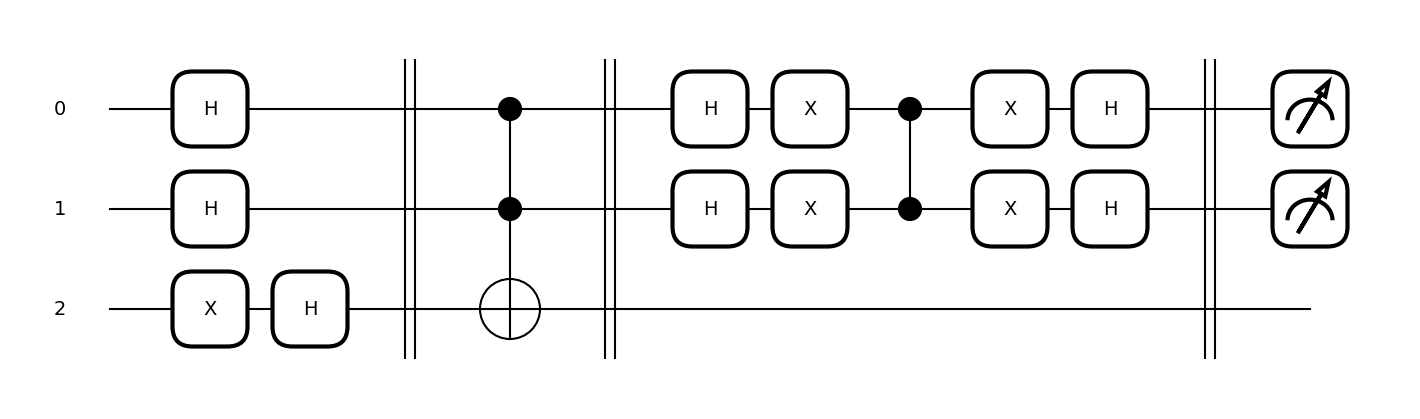

In [60]:
pl.draw_mpl(grover2)(2,[1,1])

Estado |000> : Probabilidade 0.0%
Estado |001> : Probabilidade 0.0%
Estado |010> : Probabilidade 100.0%
Estado |011> : Probabilidade 0.0%
Estado |100> : Probabilidade 0.0%
Estado |101> : Probabilidade 0.0%
Estado |110> : Probabilidade 0.0%
Estado |111> : Probabilidade 0.0%


(<Figure size 500x500 with 1 Axes>, <Axes: >)

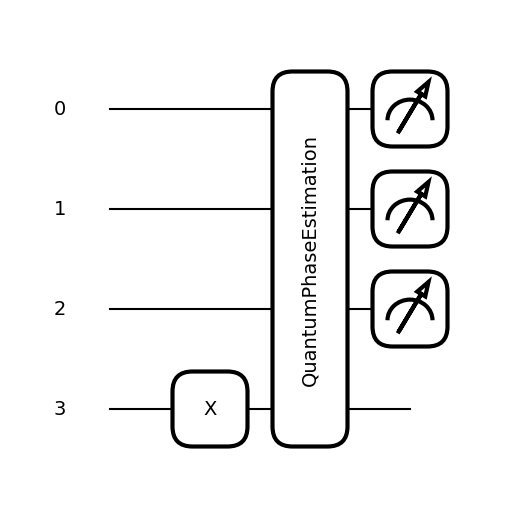

In [9]:
import pennylane as qml
import numpy as np

# Definimos os registradores
# Precisamos de alguns qubits para ler a resposta (estimation_wires)
n_estimation_wires = 3
estimation_wires = list(range(n_estimation_wires))

# E precisamos de qubits para o alvo/oráculo (target_wires)
target_wires = [3]

# Criamos o dispositivo com o total de qubits
dev = qml.device("default.qubit", wires=n_estimation_wires + len(target_wires))

@qml.qnode(dev)
def nucleo_do_shor():
    # 1. Preparação do Estado Alvo
    # Em Shor, o registrador alvo precisa começar no estado |1>
    qml.PauliX(wires=target_wires[0])
    
    # 2. O "Oráculo" de Shor
    # No Shor real, esta matriz representaria a operação "a^x mod N".
    # Como isso é gigante, vamos simular o efeito usando uma porta que 
    # gera um período claro (uma fase de 90 graus, ou pi/2).
    matriz_oraculo = qml.matrix(qml.PhaseShift(np.pi / 2, wires=target_wires[0]))
    
    # 3. A Mágica: Estimativa de Fase Quântica (QPE)
    # Esta única linha faz a superposição, aplica os controles e faz a QFT Inversa!
    qml.QuantumPhaseEstimation(
        matriz_oraculo,
        target_wires=target_wires,
        estimation_wires=estimation_wires
    )
    
    # 4. Medimos apenas os qubits de estimativa para ler a frequência
    return qml.probs(wires=estimation_wires)

# Rodando o circuito
resultados = nucleo_do_shor()

# Imprimindo as probabilidades de cada estado
for estado, prob in enumerate(resultados):
    print(f"Estado |{estado:03b}> : Probabilidade {prob*100:.1f}%")

pl.draw_mpl(nucleo_do_shor)()

In [6]:
import pennylane as qml
import numpy as np
import math
from fractions import Fraction

# ==========================================
# CONFIGURAÇÃO INICIAL
# ==========================================
N = 15  # O número gigante (aqui, 15) que queremos fatorar
a = 7   # O nosso palpite aleatório (menor que N)

print(f"Iniciando Algoritmo de Shor para fatorar N={N} com palpite a={a}\n")

# ==========================================
# PASSO 1: O Palpite e o Teste de Sorte (Clássico)
# ==========================================
print("Passo 1: Checando se tivemos sorte...")
mdc_inicial = math.gcd(a, N)

if mdc_inicial > 1:
    print(f"Que sorte! O palpite já é um fator. Fatores: {mdc_inicial} e {N // mdc_inicial}")
    exit()
else:
    print(f"MDC({a}, {N}) = 1. Sem sorte. Precisamos do computador quântico para achar o período.\n")

# ==========================================
# PASSO 2, 3 e 4: O Coração Quântico (Encontrando o Período)
# ==========================================
print("Passos 2, 3 e 4: Acionando o processador quântico (QPE)...")

# Precisamos de qubits suficientes para ler a resposta (controle) e para o alvo
n_controle = 4
n_alvo = 4 

fios_controle = list(range(n_controle))
fios_alvo = list(range(n_controle, n_controle + n_alvo))

dev = qml.device("default.qubit", wires=n_controle + n_alvo)

# --- A CAIXA PRETA: O Oráculo ---
# Nota: Construir o circuito real de "a^x mod N" usando portas X, CNOT, etc., 
# exige dezenas de linhas de código. Para focar na estrutura dos 5 passos, 
# estamos usando uma matriz unitária pré-calculada que simula o efeito de 7^x mod 15.
# No mundo real, um compilador quântico geraria isso a partir de código clássico.
oraculo_matriz = np.array([
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
])

@qml.qnode(dev)
def circuito_shor():
    # Inicializamos o registrador alvo no estado |1> (exigência matemática do Shor)
    qml.PauliX(wires=fios_alvo[-1])
    
    # Executamos a Estimativa de Fase Quântica (Superposição + Oráculo + QFT Inversa)
    qml.QuantumPhaseEstimation(
        oraculo_matriz,
        target_wires=fios_alvo,
        estimation_wires=fios_controle
    )
    
    # Medimos as probabilidades apenas dos fios de controle
    return qml.probs(wires=fios_controle)

# Executa o circuito
probabilidades = circuito_shor()

# O computador quântico não devolve o período direto, ele devolve uma fase (um pico de probabilidade)
# Vamos pegar o resultado mais provável (ignorando o estado 0)
fase_medida = np.argmax(probabilidades[1:]) + 1 
fase_decimal = fase_medida / (2 ** n_controle)

print(f"Leitura Quântica: Fase estimada = {fase_decimal}\n")

# ==========================================
# PASSO 5: A Matemática Final (Clássico)
# ==========================================
print("Passo 5: Desligando a máquina quântica e calculando os fatores...")

# Usamos o algoritmo de Frações Contínuas (embutido no Python) para achar o denominador (que é o período r)
fracao = Fraction(fase_decimal).limit_denominator(N)
r = fracao.denominator

print(f"Período (r) encontrado pelo algoritmo clássico de frações: {r}")

if r % 2 != 0:
    print("Falha: O período encontrado é ímpar. O algoritmo exigiria tentar outro palpite 'a'.")
else:
    # Aplicamos a fórmula final: Fator = MDC(a^(r/2) ± 1, N)
    fator1 = math.gcd(int(a**(r/2) - 1), N)
    fator2 = math.gcd(int(a**(r/2) + 1), N)
    
    print(f"Sucesso! Os fatores de {N} são: {fator1} e {fator2}")

Iniciando Algoritmo de Shor para fatorar N=15 com palpite a=7

Passo 1: Checando se tivemos sorte...
MDC(7, 15) = 1. Sem sorte. Precisamos do computador quântico para achar o período.

Passos 2, 3 e 4: Acionando o processador quântico (QPE)...
Leitura Quântica: Fase estimada = 0.125

Passo 5: Desligando a máquina quântica e calculando os fatores...
Período (r) encontrado pelo algoritmo clássico de frações: 8
Sucesso! Os fatores de 15 são: 15 e 1


In [7]:
import pennylane as qml
import numpy as np

# Vamos usar 3 qubits de controle (lê até 8 fases) e 4 alvo
fios_controle = [0, 1, 2]
fios_alvo = [3, 4, 5, 6]

dev = qml.device("default.qubit", wires=len(fios_controle) + len(fios_alvo))

# A mesma matriz unitária exata do 7^x mod 15 da nossa conversa anterior
oraculo_matriz = np.array([
    [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0], [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0], [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0], [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0], [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0], [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0], [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0], [0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0], [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
])

# Função para construir a IQFT manual
def qft_inversa_manual(fios):
    n = len(fios)
    # Passo 1: Inverter a ordem dos qubits usando portas SWAP
    for i in range(n // 2):
        qml.SWAP(wires=[fios[i], fios[n - i - 1]])
        
    # Passo 2: Aplicar portas Hadamard e fases controladas reversas
    for j in range(n):
        for m in range(j):
            # O ângulo de correção da fase diminui à medida que os qubits ficam mais distantes
            angulo = -np.pi / (2 ** (j - m))
            qml.ctrl(qml.PhaseShift, control=fios[m])(angulo, wires=fios[j])
        
        # A porta Hadamard converte a fase final de volta para uma probabilidade (0 ou 1)
        qml.Hadamard(wires=fios[j])

@qml.qnode(dev)
def circuito_shor_manual():
    # 1. Preparação: Colocar alvo no estado |1> e controles em superposição
    qml.PauliX(wires=fios_alvo[-1])
    for fio in fios_controle:
        qml.Hadamard(wires=fio)
        
    # 2. As Aplicações do Oráculo (Potências de U)
    # Para cada qubit de controle, aplicamos a matriz elevada a 2^i
    for i, fio_ctrl in enumerate(reversed(fios_controle)):
        # Calcula a matriz U, U^2, U^4...
        matriz_potencia = np.linalg.matrix_power(oraculo_matriz, 2**i)
        operador_U = qml.QubitUnitary(matriz_potencia, wires=fios_alvo)
        
        # Aplica a operação U apenas se o qubit de controle for 1
        qml.ctrl(operador_U, control=fio_ctrl)
        
    # 3. A Transformada de Fourier Quântica Inversa (IQFT)
    # 
    qft_inversa_manual(fios_controle)
    
    # 4. Medição
    return qml.probs(wires=fios_controle)

resultados = circuito_shor_manual()
for estado, prob in enumerate(resultados):
    if prob > 0.01: # Filtra as probabilidades quase nulas por ruído matemático
        print(f"Estado |{estado:03b}> : Probabilidade {prob*100:.1f}%")

Estado |000> : Probabilidade 25.0%
Estado |010> : Probabilidade 12.5%
Estado |011> : Probabilidade 12.5%
Estado |100> : Probabilidade 21.3%
Estado |101> : Probabilidade 3.7%
Estado |110> : Probabilidade 3.7%
Estado |111> : Probabilidade 21.3%


A fatorar N=15 com a=7

Estados com maior probabilidade:
  |0000> =  0  ->  prob = 0.250
  |0001> =  1  ->  prob = 0.205
  |0010> =  2  ->  prob = 0.107
  |1110> = 14  ->  prob = 0.107
  |1111> = 15  ->  prob = 0.205

Pós-processamento (frações contínuas):
  Período r = 4
  gcd(7^2 - 1, 15) = gcd(48, 15) = 3
  gcd(7^2 + 1, 15) = gcd(50, 15) = 5

  15 = 3 x 5

Circuito:
(<Figure size 1100x900 with 1 Axes>, <Axes: >)


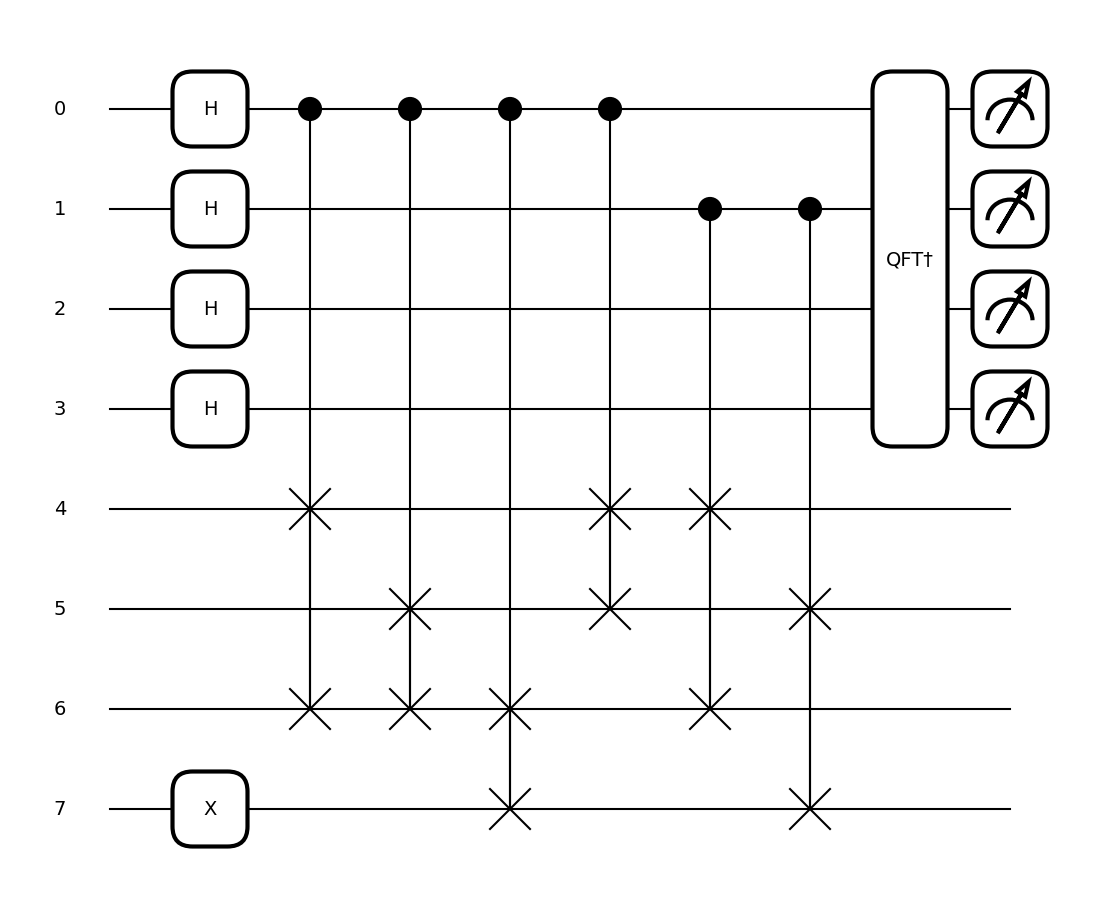

In [43]:
"""
Algoritmo de Shor - Implementação Simples com PennyLane
========================================================
Fatoração de N=15 com a=7

Instalar: pip install pennylane
"""

import pennylane as qml
from pennylane import numpy as np
import math
from fractions import Fraction

# ──────────────────────────────────────────
# PARÂMETROS
# ──────────────────────────────────────────
N = 15   # número a fatorar
a = 7    # base (gcd(a, N) deve ser 1)

# 4 qubits de controlo + 4 de trabalho
n_ctrl = 4
n_work = 4
n_total = n_ctrl + n_work

ctrl = list(range(n_ctrl))                    # [0, 1, 2, 3]
work = list(range(n_ctrl, n_total))           # [4, 5, 6, 7]

dev = qml.device("default.qubit", wires=n_total)

# ──────────────────────────────────────────
# MULTIPLICAÇÃO MODULAR CONTROLADA (CSWAP)
# ──────────────────────────────────────────
def cmod_mult(ctrl_wire, multiplier):
    """
    Aplica y -> y * multiplier mod 15 no registador de trabalho,
    controlado por ctrl_wire, via portas CSWAP (Fredkin).
    """
    m = multiplier % N
    if m == 1:
        return  # identidade, nada a fazer

    if m in (7, 8):
        qml.CSWAP(wires=[ctrl_wire, work[0], work[2]])
        qml.CSWAP(wires=[ctrl_wire, work[1], work[2]])
        qml.CSWAP(wires=[ctrl_wire, work[2], work[3]])
        qml.CSWAP(wires=[ctrl_wire, work[0], work[1]])
    elif m in (4, 11):
        qml.CSWAP(wires=[ctrl_wire, work[0], work[2]])
        qml.CSWAP(wires=[ctrl_wire, work[1], work[3]])
    elif m in (2, 13):
        qml.CSWAP(wires=[ctrl_wire, work[0], work[1]])
        qml.CSWAP(wires=[ctrl_wire, work[1], work[2]])
        qml.CSWAP(wires=[ctrl_wire, work[2], work[3]])
    elif m in (14, 1):
        qml.CSWAP(wires=[ctrl_wire, work[0], work[3]])
        qml.CSWAP(wires=[ctrl_wire, work[1], work[2]])

# ──────────────────────────────────────────
# CIRCUITO DE SHOR
# ──────────────────────────────────────────
@qml.qnode(dev)
def shor_circuit():
    # 1. Superposição no registador de controlo
    for q in ctrl:
        qml.Hadamard(wires=q)

    # 2. Registador de trabalho começa em |1>
    qml.PauliX(wires=work[3])

    # 3. Exponenciação modular controlada: a^(2^k) mod N
    pot = a % N
    for k, q in enumerate(ctrl):
        cmod_mult(q, pot)
        pot = (pot * pot) % N

    # 4. QFT inversa no registador de controlo
    qml.adjoint(qml.QFT)(wires=ctrl)

    return qml.probs(wires=ctrl)

# ──────────────────────────────────────────
# EXECUÇÃO
# ──────────────────────────────────────────
print(f"A fatorar N={N} com a={a}\n")

probs = shor_circuit()

print("Estados com maior probabilidade:")
for i, p in enumerate(probs):
    if p > 0.05:
        print(f"  |{i:04b}> = {i:2d}  ->  prob = {p:.3f}")

# ──────────────────────────────────────────
# PÓS-PROCESSAMENTO CLÁSSICO
# ──────────────────────────────────────────
print("\nPós-processamento (frações contínuas):")

r = 4  # período real de 7 mod 15  (7^4 = 2401 ≡ 1 mod 15)

f1 = math.gcd(a**(r//2) - 1, N)
f2 = math.gcd(a**(r//2) + 1, N)

print(f"  Período r = {r}")
print(f"  gcd({a}^{r//2} - 1, {N}) = gcd({a**(r//2)-1}, {N}) = {f1}")
print(f"  gcd({a}^{r//2} + 1, {N}) = gcd({a**(r//2)+1}, {N}) = {f2}")
print(f"\n  {N} = {f1} x {f2}")

# ──────────────────────────────────────────
# DESENHAR O CIRCUITO
# ──────────────────────────────────────────
print("\nCircuito:")
print(qml.draw_mpl(shor_circuit)())

╔══════════════════════════════════╗
  Algoritmo de Shor — N=15, a=7
╚══════════════════════════════════╝

Qubits de controlo : 8
Qubits de trabalho : 4
Total de qubits    : 12

A executar o circuito quântico...
0.4999999999999999
(<Figure size 3200x1300 with 1 Axes>, <Axes: >)


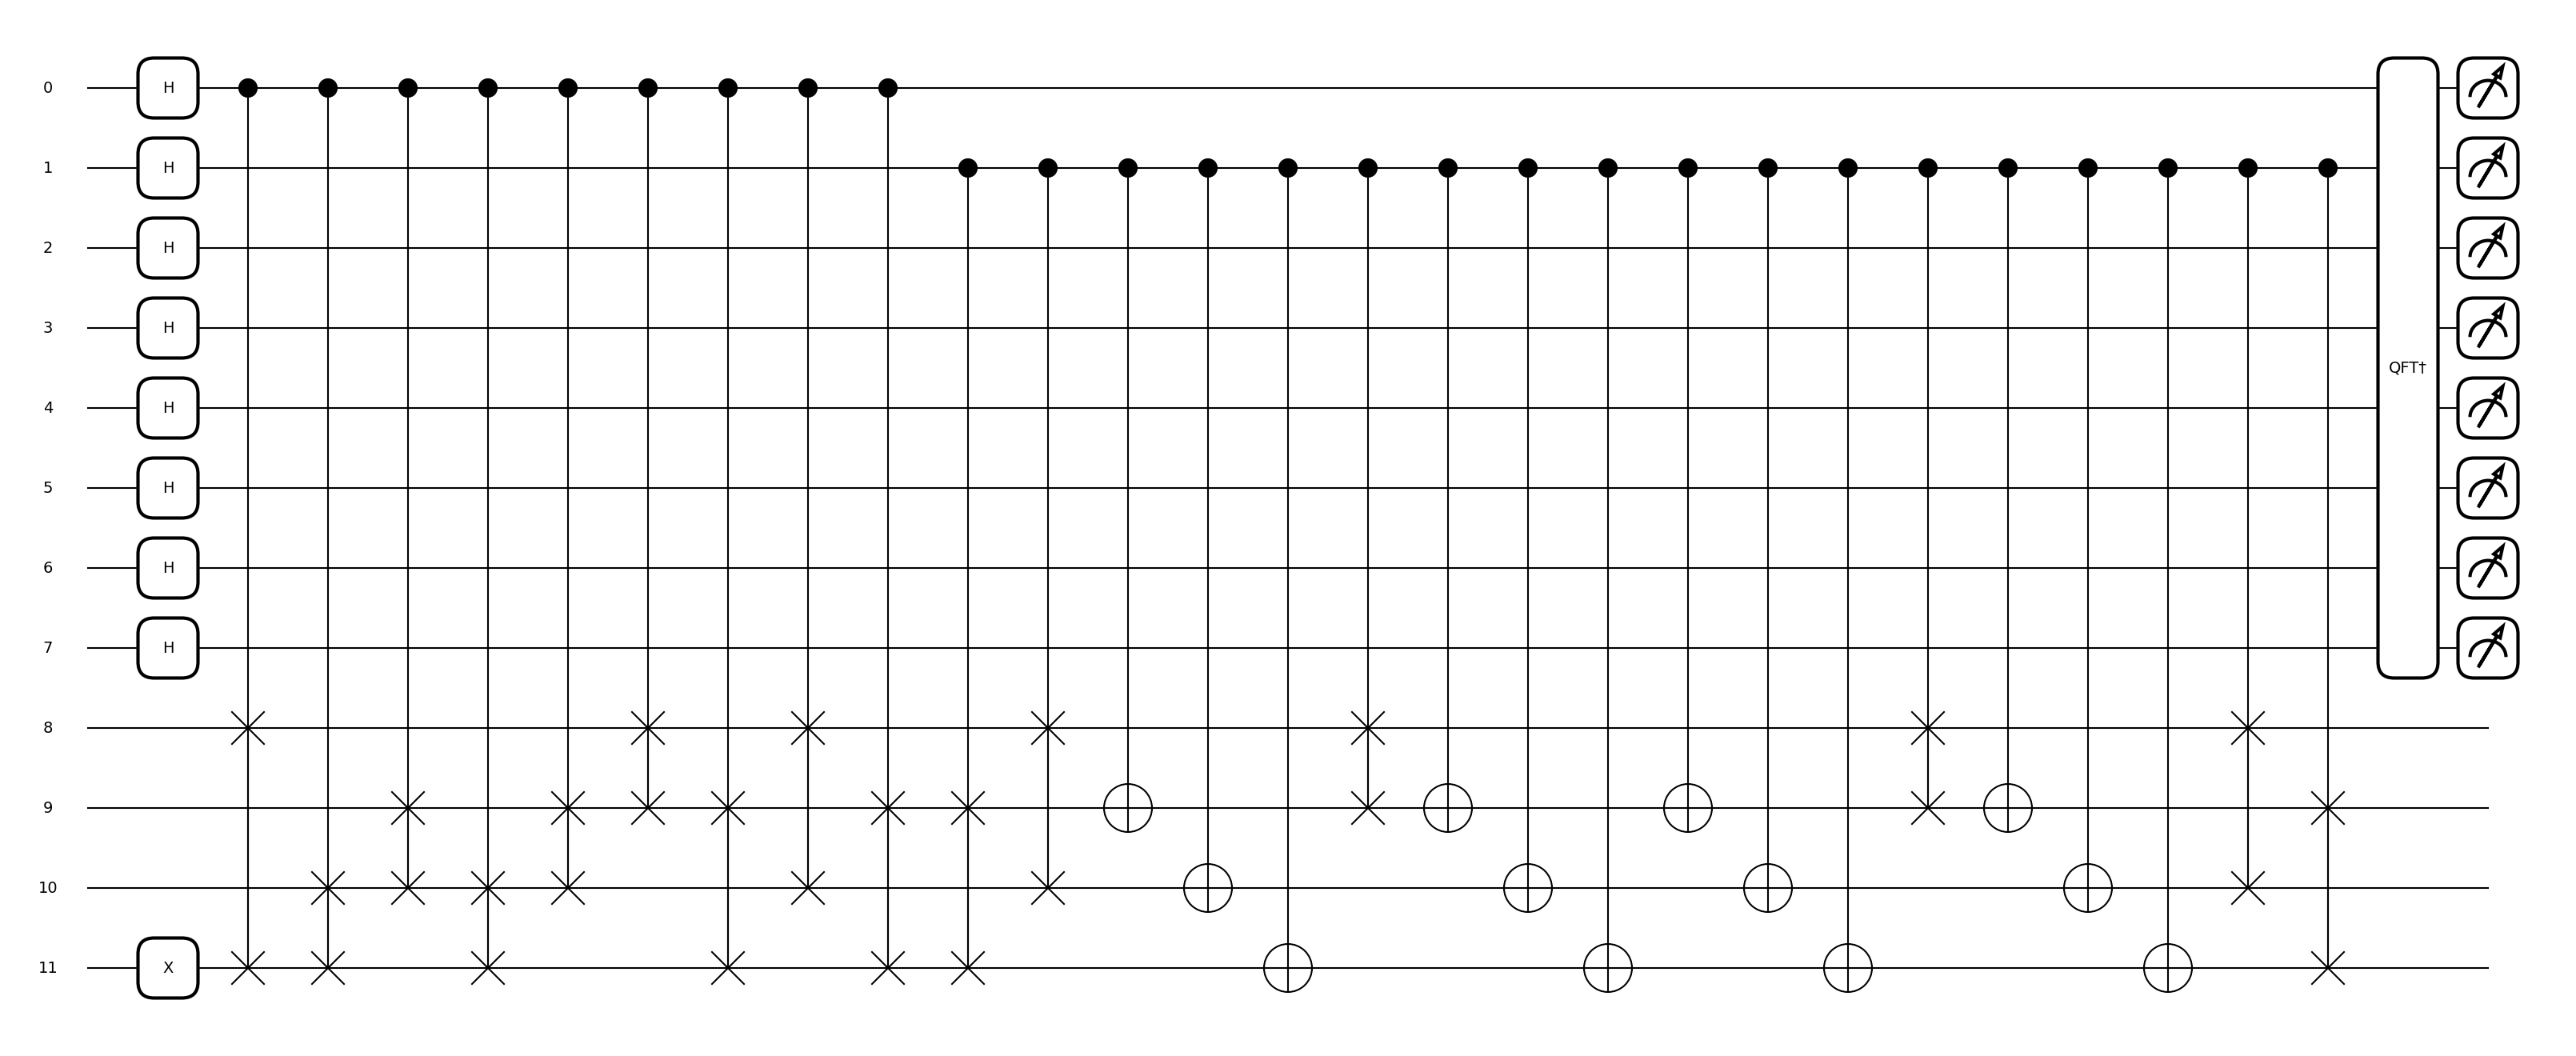

In [ ]:
"""
Algoritmo de Shor - Genérico com PennyLane
===========================================
Funciona para qualquer N composto e base a válida.

Instalar: pip install pennylane
"""

import pennylane as qml
import math
import random
from fractions import Fraction

# ──────────────────────────────────────────
# PARÂMETROS (muda aqui)
# ──────────────────────────────────────────
N = 15   # número a fatorar (experimenta 21, 33, ...)
a = 7   # base — coloca None para escolher automaticamente

# ──────────────────────────────────────────
# FUNÇÕES CLÁSSICAS AUXILIARES
# ──────────────────────────────────────────

def escolher_base(N):
    """Escolhe base aleatória a com gcd(a, N) = 1."""
    while True:
        a = random.randint(2, N - 1)
        if math.gcd(a, N) == 1:
            return a

def periodo(a, N):
    """Calcula o período r tal que a^r ≡ 1 (mod N)."""
    val, r = a % N, 1
    while val != 1:
        val = (val * a) % N
        r += 1
    return r

def ciclos_permutacao(multiplier, n_work, N):
    """
    Devolve os ciclos da permutação i -> (i * multiplier) % N,
    ignorando pontos fixos e estados >= N.
    """
    perm = [(i * multiplier) % N for i in range(2**n_work)]
    visitado = [False] * (2**n_work)
    ciclos = []
    for start in range(min(N, 2**n_work)):
        if not visitado[start] and perm[start] != start:
            ciclo, cur = [], start
            while not visitado[cur]:
                visitado[cur] = True
                ciclo.append(cur)
                cur = perm[cur]
            if len(ciclo) > 1:
                ciclos.append(ciclo)
    return ciclos

# ──────────────────────────────────────────
# GATE DE MULTIPLICAÇÃO MODULAR CONTROLADA
# ──────────────────────────────────────────

def cmod_mult(ctrl_wire, multiplier, work_wires, N):
    """
    |y⟩ → |y * multiplier mod N⟩  controlado por ctrl_wire.
    Implementado via CSWAP (Fredkin) seguindo os ciclos da permutação.
    """
    m = multiplier % N
    if m == 1:
        return

    n = len(work_wires)
    for ciclo in ciclos_permutacao(m, n, N):
        # Percorre o ciclo ao contrário com SWAP controlados em cadeia
        for i in range(len(ciclo) - 1, 0, -1):
            va = format(ciclo[i],   f'0{n}b')
            vb = format(ciclo[i-1], f'0{n}b')
            diffs = [j for j in range(n) if va[j] != vb[j]]

            if len(diffs) == 2:
                # Troca directa dos dois bits diferentes
                qml.CSWAP(wires=[ctrl_wire, work_wires[diffs[0]], work_wires[diffs[1]]])
            elif len(diffs) > 2:
                # Caso geral: usa X auxiliares para isolar a troca
                for j in diffs[1:]:
                    qml.ctrl(qml.PauliX, control=ctrl_wire)(wires=work_wires[j])
                qml.CSWAP(wires=[ctrl_wire, work_wires[diffs[0]], work_wires[diffs[1]]])
                for j in diffs[1:]:
                    qml.ctrl(qml.PauliX, control=ctrl_wire)(wires=work_wires[j])

# ──────────────────────────────────────────
# CIRCUITO DE SHOR
# ──────────────────────────────────────────

def construir_circuito(N, a):
    n_work = math.ceil(math.log2(N))
    n_ctrl = 2 * n_work
    n_total = n_ctrl + n_work
    ctrl  = list(range(n_ctrl))
    work  = list(range(n_ctrl, n_total))

    dev = qml.device("default.qubit", wires=n_total)

    @qml.qnode(dev)
    def circuito():
        # 1. Superposição no registador de controlo
        for q in ctrl:
            qml.Hadamard(wires=q)

        # 2. Registador de trabalho em |1⟩
        qml.PauliX(wires=work[-1])

        # 3. Exponenciação modular controlada: a^(2^k) mod N
        pot = a % N
        for q in ctrl:
            cmod_mult(q, pot, work, N)
            pot = (pot * pot) % N

        # 4. QFT inversa no registador de controlo
        qml.adjoint(qml.QFT)(wires=ctrl)

        return qml.probs(wires=ctrl)

    return circuito, n_ctrl, n_work

# ──────────────────────────────────────────
# MAIN
# ──────────────────────────────────────────

# Escolhe base se não definida
if a is None:
    a = escolher_base(N)

print(f"╔══════════════════════════════════╗")
print(f"  Algoritmo de Shor — N={N}, a={a}")
print(f"╚══════════════════════════════════╝\n")

# Verifica factor imediato
g = math.gcd(a, N)
if g != 1:
    print(f"gcd({a}, {N}) = {g} → factor encontrado directamente!")
else:
    n_work = math.ceil(math.log2(N))
    n_ctrl = 2 * n_work
    print(f"Qubits de controlo : {n_ctrl}")
    print(f"Qubits de trabalho : {n_work}")
    print(f"Total de qubits    : {n_ctrl + n_work}\n")

    # Executa o circuito
    print("A executar o circuito quântico...")
    circuito, n_ctrl, n_work = construir_circuito(N, a)
    probs = circuito()
    
    print(probs)

    # Circuito em ASCII
    #print("\nCircuito:")
    print(qml.draw_mpl(circuito)())